### Performance- und Kalibrationsmetriken für die Top 38 und Stable 70% Datensätze

Missing top38: []
Missing stable70: []
Validiere Datensatz: Full
Validiere Datensatz: Top-38
Validiere Datensatz: Stable-70%


,Dataset,Train Accuracy,Test Accuracy,Balanced Acc.,F1 Score,Recall,Precision,ROC-AUC,PR-AUC,Brier,LogLoss
0,Full,1.000 (1.000–1.000),0.876 (0.765–0.987),0.873 (0.757–0.987),0.859 (0.714–0.987),0.815 (0.625–1.000),0.924 (0.722–1.000),0.971 (0.924–1.000),0.973 (0.932–1.000),0.080 (0.029–0.135),0.243 (0.113–0.387)
1,Top-38,0.992 (0.985–1.000),0.901 (0.812–1.000),0.898 (0.812–1.000),0.889 (0.769–1.000),0.847 (0.625–1.000),0.946 (0.778–1.000),0.972 (0.920–1.000),0.975 (0.937–1.000),0.068 (0.023–0.114),0.218 (0.096–0.368)
2,Stable-70%,0.939 (0.897–0.970),0.855 (0.716–0.941),0.851 (0.706–0.944),0.831 (0.638–0.941),0.788 (0.528–1.000),0.900 (0.717–1.000),0.941 (0.858–1.000),0.947 (0.865–1.000),0.098 (0.042–0.170),0.307 (0.157–0.494)


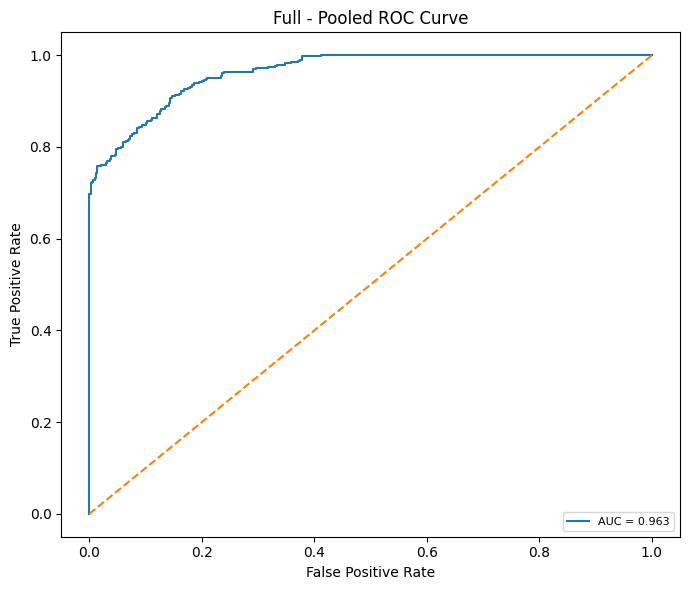

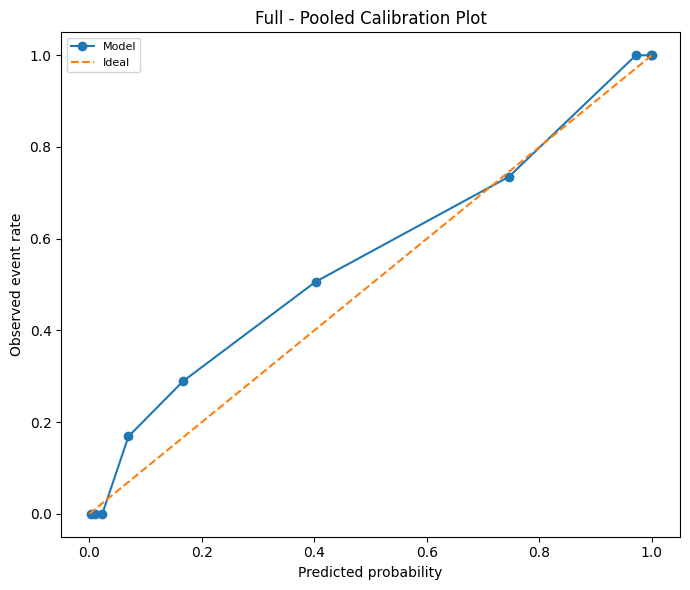

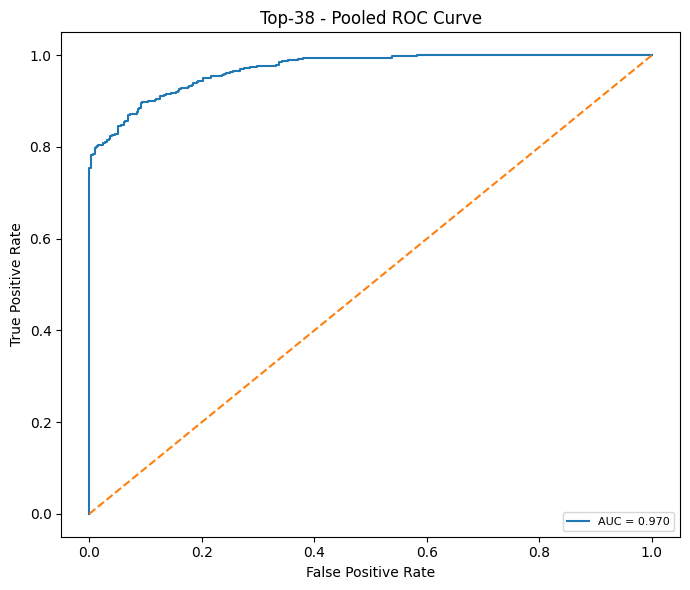

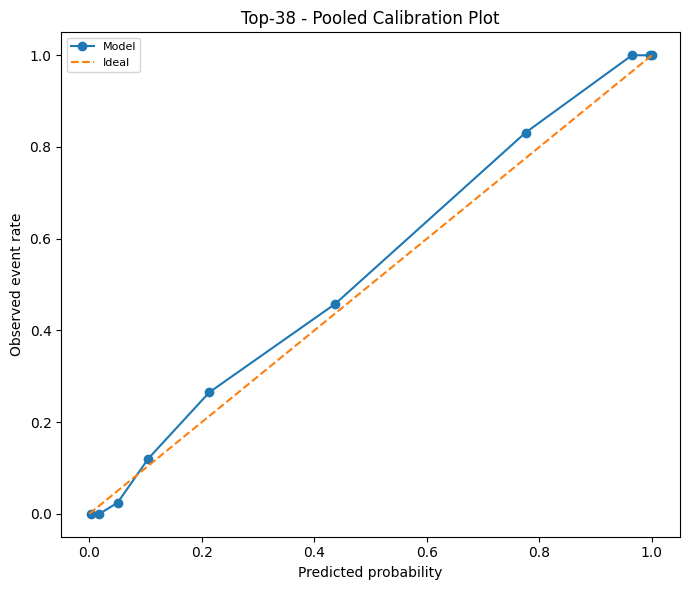

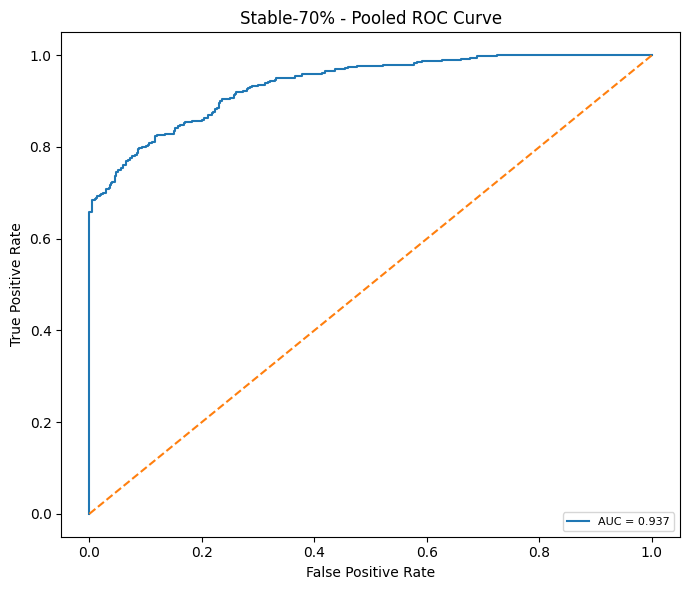

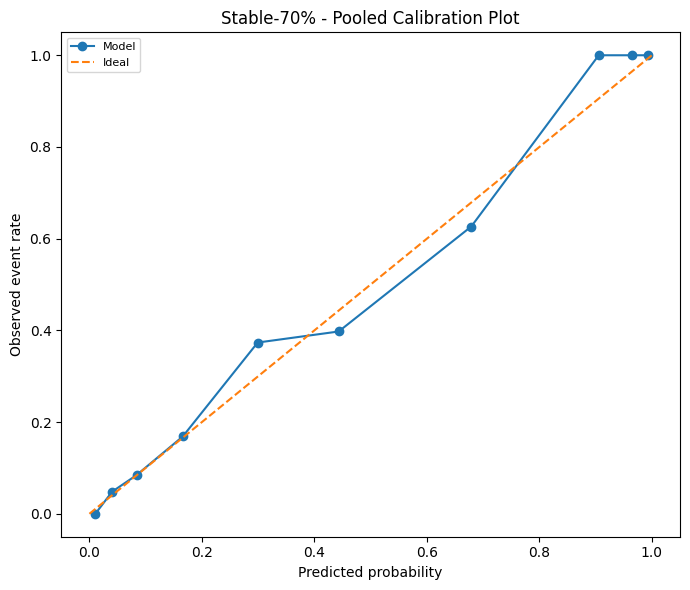

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score,
    balanced_accuracy_score, average_precision_score, brier_score_loss, log_loss,
    roc_curve
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression


# =============================================================================
# KONFIGURATION
# =============================================================================
FILE_PATH = r"K:\Team\Böhmer_Michael\PAPER\Philipp\Datensatz\Basistabelle_5_bis_14_PostOP_outlier.xlsx"
TARGET_COL = "Verletzungsstatus"

N_SPLITS = 5
N_REPEATS = 10
RANDOM_STATE = 42

# Fixe Hyperparameter aus der vorherigen Optimierung
LOGREG_C = 0.842
LOGREG_PENALTY = "l2"
LOGREG_SOLVER = "lbfgs"
LOGREG_MAX_ITER = 1000


# =============================================================================
# FIXE FEATURE-SETS
# =============================================================================
top38_features = [
    "CMJ_KAI ecc",
    "CMJ_KAI con",
    "INV_ISO_Arbeit_Unterschied Extension Flexion",
    "UNINV_ISO_Max Flexion",
    "INV_ISO_Drehmoment_Unterschied Extension Flexion",
    "UNINV_CMJ_uni_Relative Peak Landing Force-Mittelwert [BW]",
    "INV_CMJ_uni_Max Rate of Force Development-Mittelwert [N/s]",
    "INV_ISO_Drehmoment_Verhaeltnis Flexion Extension",
    "INV_Arbeit_Flexion",
    "UNINV_CMJ_uni_Bremsimpuls-Mittelwert [N*s]",
    "INV_ISO_Arbeit_Verhaeltnis Flexion Extension",
    "UNINV_CMJ_uni_Av. propulsive force",
    "INV_CMJ_uni_Peak braking force",
    "ISO_Arbeit_Seitenunterschied Flexion absolut",
    "CMJ_Braking duration",
    "CMJ_Countermovement depth",
    "UNINV_CMJ_uni_Relative Peak Loading Force-Mittelwert [BW]",
    "CMJ_Jump Height impulse",
    "CMJ_Rel. peak loading force",
    "CMJ_Propulsive duration",
    "INV_Arbeit_Extension",
    "INV_CMJ_uni_Net Impulse-Mittelwert [N*s]",
    "CMJ_Vertical Stiffness",
    "UNINV_CMJ_uni_Braking Duration-Mittelwert [s]",
    "UNINV_ISO_Drehmoment_Verhaeltnis Flexion Extension",
    "ISO_Drehmoment_Seitenunterschied Extension absolut",
    "UNINV_CMJ_uni_Max Rate of Force Development-Mittelwert [N/s]",
    "CMJ_Jump Height flighttime",
    "CMJ_Rel. Peak landing force",
    "INV_CMJ_uni_Av. propulsive force",
    "INV_CMJ_uni_Durchschnittliche Bremsleistung-Mittelwert [Watt]",
    "ISO_Drehmoment_Seitenunterschied Extension relativ",
    "UNINV_CMJ_uni_Peak Braking Force-Mittelwert [N]",
    "INV_CMJ_uni_Relative Peak Loading Force-Mittelwert [BW]",
    "INV_CMJ_uni_Durchschnittliche Bremsgeschwindigkeit-Mittelwert [m/s]",
    "UNINV_ISO_Drehmoment_Unterschied Extension Flexion",
    "Geschlecht_weiblich",
    "INV_CMJ_uni_Vertical Stiffness-Mittelwert [kN/m]",
]

stable70_features = [
    "CMJ_KAI ecc",
    "CMJ_KAI con",
    "INV_ISO_Arbeit_Unterschied Extension Flexion",
    "UNINV_ISO_Max Flexion",
    "INV_ISO_Drehmoment_Unterschied Extension Flexion",
    "UNINV_CMJ_uni_Relative Peak Landing Force-Mittelwert [BW]",
    "INV_CMJ_uni_Max Rate of Force Development-Mittelwert [N/s]",
    "INV_ISO_Drehmoment_Verhaeltnis Flexion Extension",
    "INV_Arbeit_Flexion",
    "UNINV_CMJ_uni_Bremsimpuls-Mittelwert [N*s]",
    "INV_ISO_Arbeit_Verhaeltnis Flexion Extension",
    "UNINV_CMJ_uni_Av. propulsive force",
    "INV_CMJ_uni_Peak braking force",
    "ISO_Arbeit_Seitenunterschied Flexion absolut",
]


# =============================================================================
# HILFSFUNKTIONEN
# =============================================================================
def empirical_ci(values, alpha=0.05):
    values = np.asarray(values, dtype=float)
    mean_val = np.mean(values)
    low = np.percentile(values, 100 * (alpha / 2))
    high = np.percentile(values, 100 * (1 - alpha / 2))
    return mean_val, low, high


def fmt_ci(mean_val, low, high, decimals=3):
    return f"{mean_val:.{decimals}f} ({low:.{decimals}f}–{high:.{decimals}f})"


def proba_or_decision(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s_min, s_max = np.min(s), np.max(s)
        return (s - s_min) / (s_max - s_min + 1e-12)
    return (model.predict(X) == 1).astype(float)


def make_logreg_pipeline():
    return Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(
            C=LOGREG_C,
            penalty=LOGREG_PENALTY,
            solver=LOGREG_SOLVER,
            max_iter=LOGREG_MAX_ITER,
            random_state=RANDOM_STATE
        ))
    ])


def repeated_k_fold_logreg(X_df: pd.DataFrame, y_vec, n_splits=5, n_repeats=10):
    le = LabelEncoder()
    y = le.fit_transform(y_vec)
    if len(le.classes_) != 2:
        raise ValueError("Dieses Setup erwartet binäre Klassifikation (2 Klassen).")

    rkf = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=RANDOM_STATE
    )

    pipe = make_logreg_pipeline()

    metrics = {
        "acc_tr": [], "acc_te": [], "bacc": [],
        "f1": [], "rec": [], "prec": [],
        "roc": [], "prauc": [],
        "brier": [], "logloss": []
    }

    y_true_all = []
    y_score_all = []

    X = X_df.values

    for tr, te in rkf.split(X, y):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        pipe.fit(Xtr, ytr)

        ytr_pred = pipe.predict(Xtr)
        yte_pred = pipe.predict(Xte)
        yte_score = proba_or_decision(pipe, Xte)
        yte_score = np.clip(yte_score, 1e-7, 1 - 1e-7)

        metrics["acc_tr"].append(accuracy_score(ytr, ytr_pred))
        metrics["acc_te"].append(accuracy_score(yte, yte_pred))
        metrics["bacc"].append(balanced_accuracy_score(yte, yte_pred))
        metrics["f1"].append(f1_score(yte, yte_pred, zero_division=0))
        metrics["rec"].append(recall_score(yte, yte_pred, zero_division=0))
        metrics["prec"].append(precision_score(yte, yte_pred, zero_division=0))
        metrics["roc"].append(roc_auc_score(yte, yte_score))
        metrics["prauc"].append(average_precision_score(yte, yte_score))
        metrics["brier"].append(brier_score_loss(yte, yte_score))
        metrics["logloss"].append(log_loss(yte, yte_score))

        y_true_all.extend(yte.tolist())
        y_score_all.extend(yte_score.tolist())

    metrics["y_true_all"] = np.array(y_true_all)
    metrics["y_score_all"] = np.array(y_score_all)

    return metrics


def summarize_one_result(name, m, alpha=0.05):
    acc_tr_mean, acc_tr_low, acc_tr_high = empirical_ci(m["acc_tr"], alpha=alpha)
    acc_te_mean, acc_te_low, acc_te_high = empirical_ci(m["acc_te"], alpha=alpha)
    bacc_mean, bacc_low, bacc_high = empirical_ci(m["bacc"], alpha=alpha)
    f1_mean, f1_low, f1_high = empirical_ci(m["f1"], alpha=alpha)
    rec_mean, rec_low, rec_high = empirical_ci(m["rec"], alpha=alpha)
    prec_mean, prec_low, prec_high = empirical_ci(m["prec"], alpha=alpha)
    roc_mean, roc_low, roc_high = empirical_ci(m["roc"], alpha=alpha)
    prauc_mean, prauc_low, prauc_high = empirical_ci(m["prauc"], alpha=alpha)
    brier_mean, brier_low, brier_high = empirical_ci(m["brier"], alpha=alpha)
    logloss_mean, logloss_low, logloss_high = empirical_ci(m["logloss"], alpha=alpha)

    return {
        "Dataset": name,
        "Train Accuracy": fmt_ci(acc_tr_mean, acc_tr_low, acc_tr_high),
        "Test Accuracy": fmt_ci(acc_te_mean, acc_te_low, acc_te_high),
        "Balanced Acc.": fmt_ci(bacc_mean, bacc_low, bacc_high),
        "F1 Score": fmt_ci(f1_mean, f1_low, f1_high),
        "Recall": fmt_ci(rec_mean, rec_low, rec_high),
        "Precision": fmt_ci(prec_mean, prec_low, prec_high),
        "ROC-AUC": fmt_ci(roc_mean, roc_low, roc_high),
        "PR-AUC": fmt_ci(prauc_mean, prauc_low, prauc_high),
        "Brier": fmt_ci(brier_mean, brier_low, brier_high),
        "LogLoss": fmt_ci(logloss_mean, logloss_low, logloss_high),
    }


def plot_pooled_roc(y_true, y_score, title):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_val = roc_auc_score(y_true, y_score)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {auc_val:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_pooled_calibration(y_true, y_score, title, n_bins=10):
    prob_true, prob_pred = calibration_curve(
        y_true,
        y_score,
        n_bins=n_bins,
        strategy="quantile"
    )

    plt.figure(figsize=(7, 6))
    plt.plot(prob_pred, prob_true, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Ideal")
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed event rate")
    plt.title(title)
    plt.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


# =============================================================================
# MAIN
# =============================================================================
if __name__ == "__main__":
    # Daten laden
    df = pd.read_excel(FILE_PATH)
    df.columns = df.columns.str.strip()

    # Feature-Listen ebenfalls strippen, damit trailing spaces kein Problem sind
    top38_features = [f.strip() for f in top38_features]
    stable70_features = [f.strip() for f in stable70_features]

    if TARGET_COL not in df.columns:
        raise ValueError(f"Zielvariable '{TARGET_COL}' nicht in Datei gefunden.")

    y = df[TARGET_COL]

    df_num = df.drop(columns=[TARGET_COL]).copy()
    for c in df_num.columns:
        if df_num[c].dtype == "object":
            df_num[c] = pd.to_numeric(df_num[c], errors="ignore")

    X_full = df_num.select_dtypes(include=[np.number]).copy()
    X_full.columns = X_full.columns.str.strip()

    if X_full.shape[1] == 0:
        raise ValueError("Keine numerischen Features gefunden.")

    # Missing-Check
    missing_top38 = [c for c in top38_features if c not in X_full.columns]
    missing_stable70 = [c for c in stable70_features if c not in X_full.columns]

    print("Missing top38:", missing_top38)
    print("Missing stable70:", missing_stable70)

    if missing_top38 or missing_stable70:
        raise ValueError("Einige Feature-Namen matchen nicht mit den Spaltennamen.")

    # Reduzierte Datensätze
    X_top38 = X_full[top38_features].copy()
    X_stable70 = X_full[stable70_features].copy()

    datasets = {
        "Full": X_full,
        "Top-38": X_top38,
        "Stable-70%": X_stable70
    }

    # CV laufen lassen
    rows = []
    all_metrics = {}

    for ds_name, X_ds in datasets.items():
        print(f"Validiere Datensatz: {ds_name}")
        metrics = repeated_k_fold_logreg(
            X_ds,
            y,
            n_splits=N_SPLITS,
            n_repeats=N_REPEATS
        )
        all_metrics[ds_name] = metrics
        rows.append(summarize_one_result(ds_name, metrics, alpha=0.05))

    results_df = pd.DataFrame(rows)
    display(results_df)

    # ROC- und Kalibrationsplots
    for ds_name in datasets.keys():
        plot_pooled_roc(
            all_metrics[ds_name]["y_true_all"],
            all_metrics[ds_name]["y_score_all"],
            title=f"{ds_name} - Pooled ROC Curve"
        )

        plot_pooled_calibration(
            all_metrics[ds_name]["y_true_all"],
            all_metrics[ds_name]["y_score_all"],
            title=f"{ds_name} - Pooled Calibration Plot",
            n_bins=10
        )